# Giving Claude a Zoom Tool for Reading Fine Image Detail

## Introduction

When a detail in an image is too small to make out, you lean in and look closer. Claude can't do that on its own: it sees an image once, at a fixed effective resolution, and when a chart label or a pair of closely spaced lines is too small at that resolution, no amount of prompting recovers it.

The zoom tool gives Claude the lean-in move.

When Claude asks for a closer look at a region, the tool crops that region out of the full-resolution original image and returns it magnified, so the small thing becomes legible. This notebook builds that tool, and on a public chart-reading benchmark it more than doubles accuracy (results below). Why magnification works, in terms of how Claude actually sees images, comes a little later.

**By the end of this cookbook, you'll be able to:**

- Pre-resize images with the public docs' `resized_size()` reference implementation, so the pixel coordinates Claude emits map 1:1 onto the image you hold
- Define a self-contained zoom tool — absolute pixel coordinates in, a budget-filling magnified crop out — you can lift into any project
- Run the agentic loop around it, including the stop-reason handling that keeps long, thinking-heavy turns from silently truncating

Charts are this notebook's running example, but the same pattern applies anywhere detail is small relative to the image: dense documents, UI screenshots, schematics, scanned forms, photos of labels.

![The zoom-tool loop: one user message carries the question and the chart image to Claude; Claude sees the image in 28-by-28-pixel patches, and when a detail is too small it calls zoom(x1, y1, x2, y2) in pixel coordinates; your handle_zoom() implementation crops that region from the full-resolution original and returns it magnified; the exchange repeats until Claude answers — here, that the Widget-E line is higher.](../images/crop_tool/architecture_diagram.png)

## The Results, Up Front

### An example problem

![A dense six-series line chart of monthly production by product line, with a tiny peak annotation and several close crossings.](../images/crop_tool/example_problem.png)

**At month 48, which product line has the higher value: Widget-A or Widget-E?** At that month the two lines sit about 26 units apart — roughly 8 pixels in this rendering — right next to a genuine crossing. (This is a demonstration problem this notebook generates for itself, in the style of the dense real-world charts the benchmark below uses; the benchmark's own questions are a held-out evaluation set and are not reproduced here.)

### With and without the tool

Asked cold, the model answers **Widget-A** — confidently, usually narrating the nearby crossing as if it had already happened — and it is wrong in 36 of 40 recorded attempts (90%). Given the zoom tool, it zooms in on the crossing repeatedly, each crop tighter than the last, reads the ordering from the magnified view, and answers **Widget-E** — correctly, in 40 of 40 recorded attempts (100%) with exactly the code this notebook builds. (Those are repeated runs of this one demonstration problem; the benchmark numbers below are a separate, single-pass measurement.) You will run exactly this exchange yourself later in the notebook.

### The numbers

The same pattern, measured on [Chartography](https://huggingface.co/datasets/surgeai/chartography) — a public benchmark from Surge AI of 100 chart-reading questions over dense, real-world charts — by asking every question twice per model (with and without the tool) and grading free-form answers with a model judge per the dataset card. Each bar below is one model in one condition — accuracy over all 100 questions — and the arrows mark what adding the tool changes; mean per-question costs are in the figure note. The tool buys its accuracy with extra tokens: each zoom call re-sends the conversation plus a magnified crop.

![Grouped bar chart of accuracy on Chartography: for each model, a translucent bar for the no-tool condition and a solid bar for the zoom-tool condition, with an arrow marking the improvement. claude-fable-5 rises from 29% to 73% (+44 points); claude-sonnet-5 from 13% to 44% (+31 points). The figure note lists mean cost per question: claude-fable-5 $0.08 without the tool and $0.95 with it; claude-sonnet-5 $0.02 and $0.64.](../images/crop_tool/results_accuracy.png)

These numbers come from running the benchmark against the public Claude API with the models named on the chart: accuracy over all 100 questions per model per condition (2026-07-18), and cost as the mean of a 30-question usage sample (2026-07-19) at public API prices (Sonnet 5 at its introductory price), judge excluded. The zoom arms were measured with prompt caching and the no-tool arms as single uncached calls, since caching does not apply to one-shot requests; the loop's wrap-up call misses the cache, so an optimized client runs slightly cheaper.

> **Note:** Chartography is a held-out evaluation set — don't use it for training (the [dataset card](https://huggingface.co/datasets/surgeai/chartography) ships a canary string for exactly that purpose). Prompts, golden answers, and metadata are © Surge AI, CC BY 4.0. Chart images sourced from the web remain the property of their original rights holders; this cookbook redistributes nothing from the dataset.

## Prerequisites

**Required Knowledge:**
- Python fundamentals
- Basic familiarity with [tool use](https://platform.claude.com/docs/en/agents-and-tools/tool-use/overview) in the Messages API

**Required Tools:**
- Python 3.11 or higher
- Anthropic API key ([get one here](https://console.anthropic.com))

## Setup

In [1]:
%pip install -q anthropic pillow matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import base64
from collections.abc import Iterable, Mapping
from io import BytesIO
from typing import Any, cast

from anthropic import Anthropic
from IPython.display import Image, display
from PIL import Image as PILImage

client = Anthropic()
MODEL = "claude-fable-5"

## Create a Demo Chart

We'll draw the kind of chart the zoom tool exists for: six series, a dense grid, and the answer to our question printed in deliberately tiny type. Generating it ourselves means we know the ground truth exactly — and that the annotation is genuinely too small to read in the full view.

Chart size: (1325, 777)
Question: What exact value is annotated at the peak of the Widget-C line?


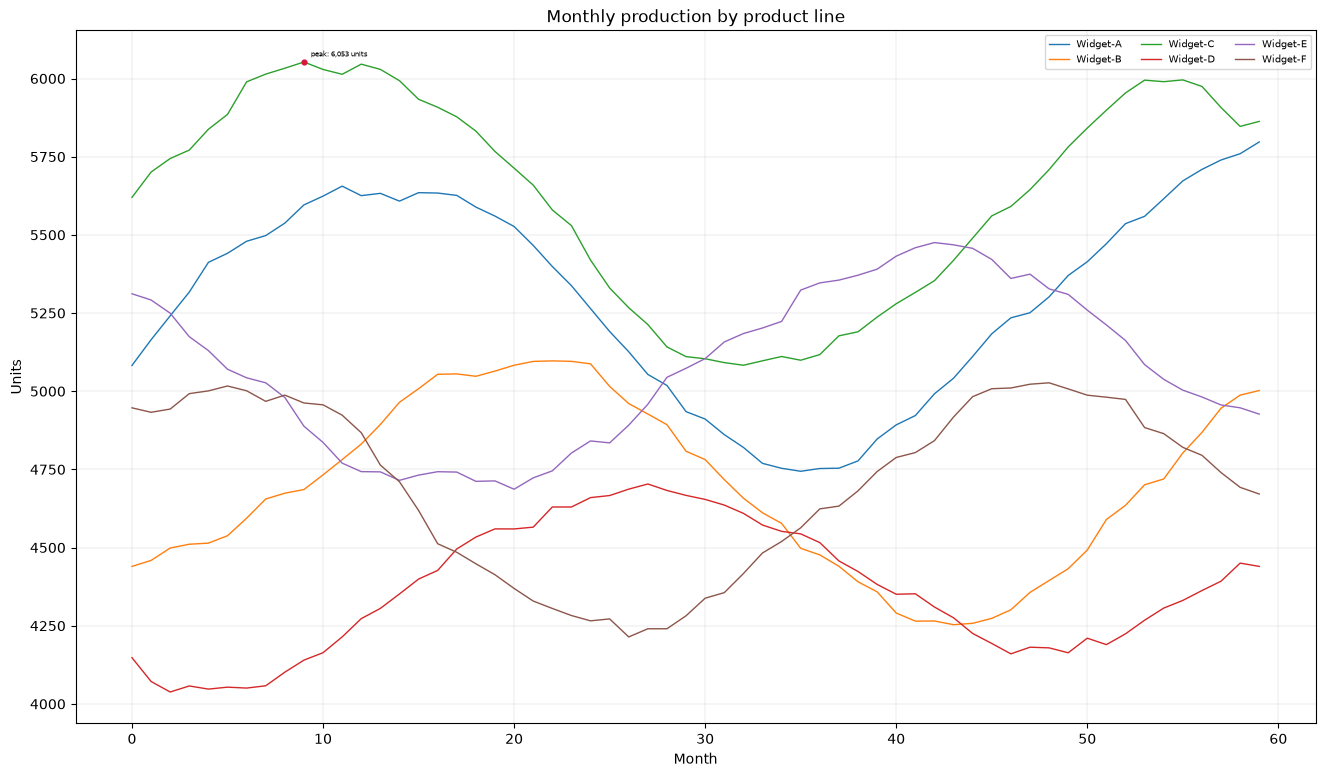

In [3]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(12)
months = np.arange(60)
fig, ax = plt.subplots(figsize=(16, 9), dpi=100)
series = {}
for name, base, amp in [
    ("Widget-A", 5200, 420),
    ("Widget-B", 4800, 380),
    ("Widget-C", 5600, 450),
    ("Widget-D", 4400, 300),
    ("Widget-E", 5014, 340),
    ("Widget-F", 4600, 410),
]:
    y = base + amp * np.sin(months / 7 + base % 7) + rng.normal(0, 90, months.size).cumsum() / 4
    series[name] = y
    ax.plot(months, y, lw=1.0, label=name)

# The detail our question hinges on: a tiny annotation at Widget-C's peak
peak_x = int(np.argmax(series["Widget-C"]))
peak_y = float(series["Widget-C"][peak_x])
ax.scatter([peak_x], [peak_y], s=12, color="crimson", zorder=3)
ax.annotate(
    f"peak: {peak_y:,.0f} units",
    (peak_x, peak_y),
    textcoords="offset points",
    xytext=(5, 4),
    fontsize=5,
)

ax.set_title("Monthly production by product line")
ax.set_xlabel("Month")
ax.set_ylabel("Units")
ax.grid(True, lw=0.3, alpha=0.6)
ax.legend(fontsize=7, ncols=3)

# Hand the figure to the rest of the notebook as a PIL image
buffer = BytesIO()
fig.savefig(buffer, format="PNG", bbox_inches="tight")
plt.close(fig)
buffer.seek(0)
chart_image = PILImage.open(buffer)

question = "What exact value is annotated at the peak of the Widget-C line?"
answer = f"peak: {peak_y:,.0f} units"

print(f"Chart size: {chart_image.size}")
print(f"Question: {question}")
_buf = BytesIO()
chart_image.save(_buf, format="PNG")
display(Image(data=_buf.getvalue(), width=560))

## How Claude Sees Images — and Why Pixel Coordinates

Two facts about [how Claude processes images](https://platform.claude.com/docs/en/build-with-claude/vision#evaluate-image-size) shape the design of the tool:

1. **Images are measured in visual tokens.** An image costs one visual token per 28×28-pixel patch, and each model has an image budget: on the standard resolution tier, no side may exceed 1568 pixels and an image may cost at most 1568 visual tokens; high-resolution-tier models (such as `claude-fable-5` and `claude-sonnet-5`) allow 2576 pixels and 4784 visual tokens. Images over the limits are automatically scaled down before Claude sees them — and small details scale down with them.

2. **Claude works best with absolute pixel coordinates.** The [vision coordinates guide](https://platform.claude.com/docs/en/build-with-claude/vision-coordinates) recommends asking for pixel coordinates explicitly, and recommends *against* normalized (0–1) coordinates. One catch: the coordinates Claude uses are pixel positions in the image *Claude saw* — after any automatic downscaling. The fix is to resize the image yourself before uploading, so the image you hold is exactly the image Claude sees, and every coordinate maps 1:1.

The coordinates guide provides a reference implementation, `resized_size()`, that computes the exact size Claude resizes an image to. We copy it below and use it twice:

- **Before uploading:** resize the image we show Claude, so that the zoom coordinates it sends us map 1:1 onto the image we have.
- **When zooming:** scale the cropped region *up* to the largest size within the budget, so every element in it gets as many patches as possible.

## Define the Zoom Tool

The flow for each zoom call:

1. Claude requests a region as pixel coordinates `(x1, y1)`–`(x2, y2)`, with the origin `(0, 0)` at the top-left corner (x increases to the right, y increases downward).
2. We map those coordinates onto the full-resolution original (which may be larger than the copy Claude saw) and crop the region from it.
3. We scale the crop up to the largest size the image budget allows and return it.

Cropping from the original rather than from the downscaled copy means the zoom works with every pixel the source image has.

One practical detail: zoomed crops are returned as JPEG rather than PNG. Tool results accumulate in the conversation, and a few full-budget PNG crops of a detailed chart can exceed the API's [32 MB request size limit](https://platform.claude.com/docs/en/api/overview#request-size-limits). (For conversations that accumulate many large images, the [Files API](https://platform.claude.com/docs/en/build-with-claude/files) keeps request payloads small regardless of history length.)

The next cell is self-contained — schema and implementation, no other cells needed — so you can copy it directly into your own project.

In [4]:
# The zoom tool: schema + implementation. This cell is self-contained (it needs
# only Pillow, plus the anthropic SDK for its type annotations), so you can copy it
# straight into your own project.
import base64
import math
from io import BytesIO

from anthropic.types import ImageBlockParam, TextBlockParam, ToolParam
from PIL import Image as PILImage

# Image limits for the model you're using — see "Resolution and token cost":
# https://platform.claude.com/docs/en/build-with-claude/vision#evaluate-image-size
MAX_EDGE = 2576  # high-resolution tier; use 1568 for standard-tier models
MAX_TOKENS = 4784  # high-resolution tier; use 1568 for standard-tier models


def count_image_tokens(width: int, height: int) -> int:
    """Visual tokens consumed by an image: one token per 28x28 pixel patch."""
    return math.ceil(width / 28) * math.ceil(height / 28)


# Reference implementation from the vision coordinates guide ("Resize your image
# before uploading"):
# https://platform.claude.com/docs/en/build-with-claude/vision-coordinates#resize-your-image-before-uploading
def resized_size(
    width: int,
    height: int,
    max_edge: int = MAX_EDGE,
    max_tokens: int = MAX_TOKENS,
) -> tuple[int, int]:
    """The size Claude resizes an image to before padding.

    Images that already fit within the limits are returned unchanged.
    """

    def fits(w: int, h: int) -> bool:
        return (
            math.ceil(w / 28) * 28 <= max_edge
            and math.ceil(h / 28) * 28 <= max_edge
            and count_image_tokens(w, h) <= max_tokens
        )

    if fits(width, height):
        return (width, height)
    if height > width:
        resized_h, resized_w = resized_size(height, width, max_edge, max_tokens)
        return (resized_w, resized_h)

    # Binary search along the long edge for the largest aspect-preserving
    # size that fits.
    aspect_ratio = width / height
    lo, hi = 1, width  # lo always fits; hi never fits
    while lo + 1 < hi:
        mid = (lo + hi) // 2
        if fits(mid, max(round(mid / aspect_ratio), 1)):
            lo = mid
        else:
            hi = mid
    return (lo, max(round(lo / aspect_ratio), 1))


def prepare_image(image: PILImage.Image) -> PILImage.Image:
    """Resize an image to exactly the size Claude will see.

    The pixel coordinates Claude uses refer to the image it saw — after any
    automatic server-side downscaling. Doing the same resize client-side first
    means Claude's coordinates map 1:1 onto the image we hold.
    """
    target = resized_size(image.width, image.height)
    if (image.width, image.height) == target:
        return image
    return image.resize(target, PILImage.Resampling.LANCZOS)


def zoom_size(width: int, height: int) -> tuple[int, int]:
    """The largest aspect-preserving size within the image limits.

    This is the upscale target for a zoomed crop: the larger the crop is drawn,
    the more 28x28 patches each element inside it covers. resized_size() finds
    the largest size that fits whenever its input is over the limits, so we
    scale the crop's size far past the limits and let the search come back down.
    """
    return resized_size(width * 10_000, height * 10_000)


def pil_to_base64(image: PILImage.Image, format: str = "PNG") -> str:
    """Convert PIL Image to base64 string.

    Transparency is composited onto white: a bare .convert("RGB") would
    flatten transparent backgrounds (common in web charts) to black.
    """
    if image.mode != "RGB":
        rgba = image.convert("RGBA")
        background = PILImage.new("RGB", rgba.size, "white")
        background.paste(rgba, mask=rgba.getchannel("A"))
        image = background
    buffer = BytesIO()
    # subsampling=0 keeps full chroma resolution: 4:2:0 subsampling halves color
    # detail, which can smear 1-2px colored chart lines in a magnified crop.
    image.save(
        buffer, format=format, **({"quality": 92, "subsampling": 0} if format == "JPEG" else {})
    )
    return base64.standard_b64encode(buffer.getvalue()).decode("utf-8")


# Tool definition for the Anthropic API
ZOOM_TOOL: ToolParam = {
    "name": "zoom",
    "description": (
        "Zoom into a rectangular region of an image. Returns the region cropped "
        "from the full-resolution original and magnified, so that small details "
        "become legible."
    ),
    "input_schema": {
        "type": "object",
        "properties": {
            "x1": {
                "type": "integer",
                "description": "Left edge of the region, in pixels (the origin is the image's top-left corner)",
            },
            "y1": {
                "type": "integer",
                "description": "Top edge of the region, in pixels",
            },
            "x2": {
                "type": "integer",
                "description": "Right edge of the region, in pixels (must be greater than x1)",
            },
            "y2": {
                "type": "integer",
                "description": "Bottom edge of the region, in pixels (must be greater than y1)",
            },
            "image_index": {
                "type": "integer",
                "description": "Which image to zoom into, counting images in the conversation from 0. Omit when there is only one image.",
            },
        },
        "required": ["x1", "y1", "x2", "y2"],
    },
}


def handle_zoom(
    original: PILImage.Image, view_size: tuple[int, int], x1: int, y1: int, x2: int, y2: int
) -> list[TextBlockParam | ImageBlockParam]:
    """Execute a zoom call and return the tool result content for Claude.

    original is the full-resolution image; view_size is the size of the copy
    Claude saw (the output of prepare_image()), which is the coordinate space
    of x1/y1/x2/y2.
    """
    view_w, view_h = view_size
    x1, x2 = max(0, min(x1, view_w)), max(0, min(x2, view_w))
    y1, y2 = max(0, min(y1, view_h)), max(0, min(y2, view_h))
    if x1 >= x2 or y1 >= y2:
        return [
            {
                "type": "text",
                "text": "Error: invalid region (need x1 < x2 and y1 < y2, within the image)",
            }
        ]

    # Map view coordinates onto the original. The resize preserved the aspect
    # ratio, so one scale factor covers both axes.
    scale = original.width / view_w
    box = (round(x1 * scale), round(y1 * scale), round(x2 * scale), round(y2 * scale))
    cropped = original.crop(box)
    zoomed = cropped.resize(zoom_size(cropped.width, cropped.height), PILImage.Resampling.LANCZOS)

    # Zoomed crops go back as JPEG: every tool result stays in the conversation,
    # and a few full-budget PNGs of detailed charts can exceed the API's 32 MB
    # request size limit. JPEG keeps each zoom to a fraction of that.
    return [
        {
            "type": "text",
            "text": (
                f"Zoomed into ({x1},{y1})-({x2},{y2}) of the image you see at "
                f"{view_w}x{view_h}px: a {cropped.width}x{cropped.height}px region "
                f"of the original, returned magnified to {zoomed.width}x{zoomed.height}px."
            ),
        },
        {
            "type": "image",
            "source": {
                "type": "base64",
                "media_type": "image/jpeg",
                "data": pil_to_base64(zoomed, "JPEG"),
            },
        },
    ]

Let's test the zoom tool manually before handing it to Claude — zooming into the upper region of the chart where the peak annotation sits:

Original size: (1325, 777), size Claude sees: (1325, 777)
Zoomed into (0,0)-(1325,233) of the image you see at 1325x777px: a 1325x233px region of the original, returned magnified to 2576x453px.


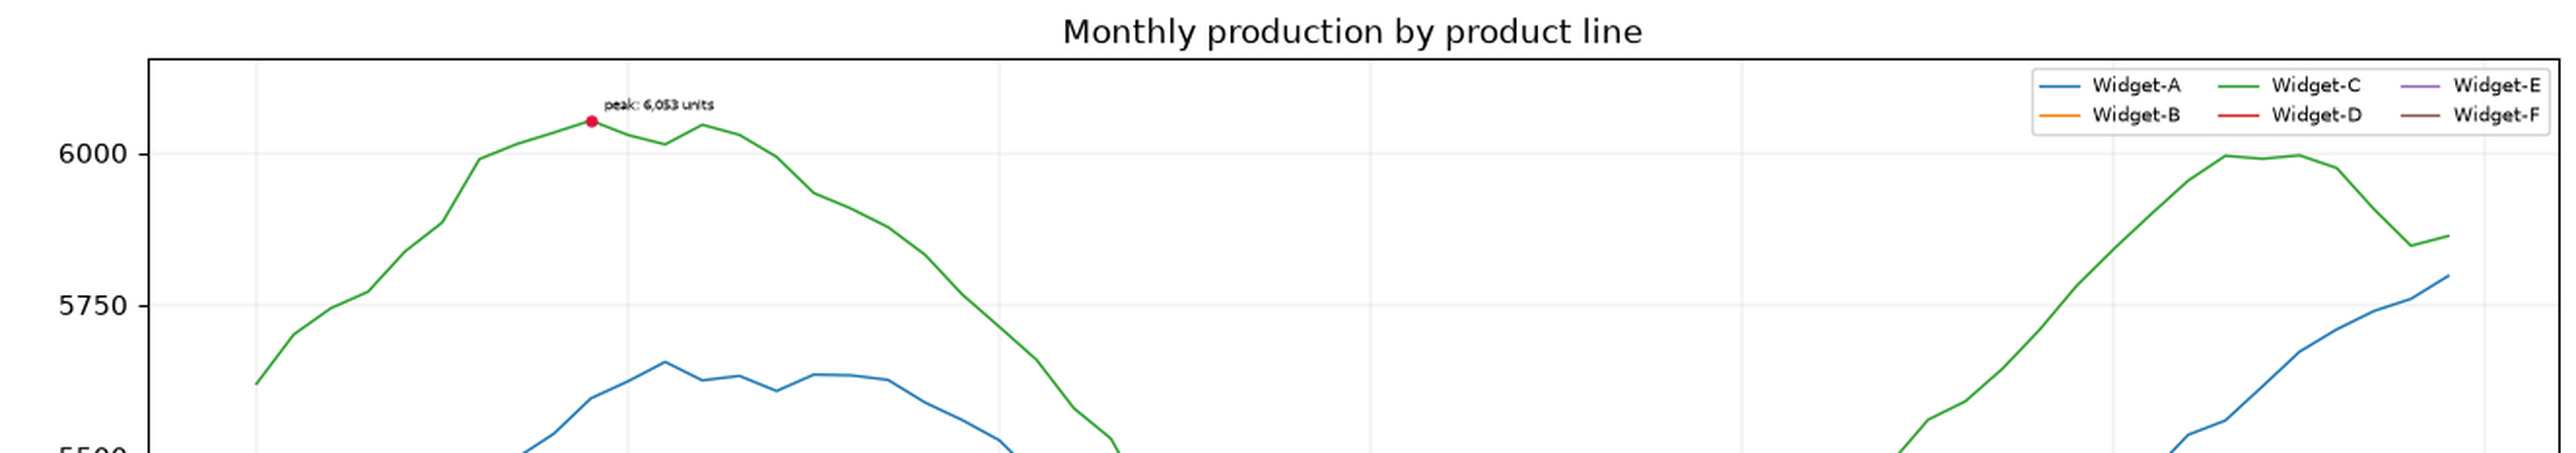

In [5]:
def show_tool_result(blocks: Iterable[Mapping[str, Any]], show_text: bool = True) -> None:
    """Print the text and display the images among a tool result's content blocks.

    A notebook convenience for inspecting what a zoom call returns. It reads the
    blocks loosely (they are plain dicts on their way to the API), so it is not
    part of the tool itself.
    """
    for block in blocks:
        if block.get("type") == "text" and show_text:
            print(block["text"])
        elif block.get("type") == "image":
            display(Image(data=base64.b64decode(block["source"]["data"]), width=400))


view = prepare_image(chart_image)
print(f"Original size: {chart_image.size}, size Claude sees: {view.size}")

# Zoom into the upper-middle band of the chart
result = handle_zoom(chart_image, view.size, x1=0, y1=0, x2=view.width, y2=int(view.height * 0.3))
show_tool_result(result)

## The Agentic Loop

Now we connect everything: send the image to Claude with the zoom tool available, and let Claude call it until it has an answer. The SDK's `tool_runner` drives the exchange — it calls our `zoom` function whenever the model asks, feeds the magnified crop back, and stops when the model answers (or after `max_iterations`, a guard against runaway loops).

Three details matter here:

- We keep **both** the full-resolution original (for the tool to crop from) and the pre-resized copy that Claude actually sees (whose size defines the coordinate space). The `zoom` function closes over both.
- The prompt **states each image's dimensions and the coordinate convention**, so Claude knows exactly which pixel space it is working in.
- `@beta_tool` builds the tool's schema from the function's signature and docstring — to add a second tool, decorate another function and add it to the `tools` list; the runner dispatches by name.

One wrinkle: the API can pause a very long turn server-side (`stop_reason == "pause_turn"`), and the runner does not yet resume these itself — the small loop around it below replays the transcript and continues when that happens.

In [6]:
from anthropic import beta_tool
from anthropic.types.beta import BetaContentBlockParam, BetaMessageParam


def ask_with_zoom_tool(images, question: str, verbose: bool = True, model: str = MODEL):
    """Ask Claude a question about one or more images, with the zoom tool available."""
    if not isinstance(images, list):
        images = [images]
    originals = images
    views = [prepare_image(image) for image in originals]

    @beta_tool
    def zoom(x1: int, y1: int, x2: int, y2: int, image_index: int = 0) -> list:
        """Zoom into a rectangular region of an image to see it magnified.

        Use this whenever text, numbers, lines, or details are too small to read
        confidently in the full view. The region is cropped from the image's
        full-resolution original and scaled up to fill the image budget, so
        small elements become much easier to read. Coordinates are absolute
        pixels in the image as you see it, origin at the top-left corner.
        Zoom again on the result for even finer detail.

        Args:
            x1: Left edge of the region in pixels (origin is the image's top-left corner).
            y1: Top edge of the region in pixels.
            x2: Right edge of the region in pixels (must be greater than x1).
            y2: Bottom edge of the region in pixels (must be greater than y1).
            image_index: Which image to zoom into (0 for the first image, 1 for the second).
        """
        if not 0 <= image_index < len(originals):
            return [{"type": "text", "text": f"Error: image_index {image_index} is out of range"}]
        return handle_zoom(originals[image_index], views[image_index].size, x1, y1, x2, y2)

    content: list[BetaContentBlockParam] = []
    for i, view in enumerate(views):
        content.append({"type": "text", "text": f"Image {i} ({view.width}x{view.height} pixels):"})
        content.append(
            {
                "type": "image",
                "source": {
                    "type": "base64",
                    "media_type": "image/png",
                    "data": pil_to_base64(view),
                },
            }
        )
    content.append(
        {
            "type": "text",
            "text": (
                f"Answer the following question about the image{'s' if len(views) > 1 else ''} "
                f"above. Coordinates are absolute pixels with the origin at the top-left corner. "
                f"Use the zoom tool to examine any detail that is too small to read confidently."
                f"\n\nThe question is: {question}"
            ),
        }
    )
    messages: list[BetaMessageParam] = [{"role": "user", "content": content}]

    runner = final = None  # bound before the loop for the type checker; the body always runs
    for _reentry in range(5):  # pause_turn re-entries are bounded, like the tool loop itself
        runner = client.beta.messages.tool_runner(
            model=model,
            max_tokens=8192,
            tools=[zoom],
            messages=messages,
            max_iterations=20,
        )
        for message in runner:
            called = [block for block in message.content if block.type == "tool_use"]
            if verbose:
                for block in called:
                    print(f"[Tool] {block.name}({block.input})")
                if called:
                    # The runner caches this response and reuses it internally, so
                    # peeking at it here does not re-run the tool. It is the
                    # tool_result message the runner sends next; its blocks are the
                    # plain dicts handle_zoom() built, so read them as such.
                    peek = cast(Any, runner.generate_tool_call_response())
                    for tool_result in peek["content"] if peek else []:
                        # An errored tool call carries a plain string instead
                        # of blocks; only successful zooms have images to show.
                        if isinstance(tool_result["content"], list):
                            show_tool_result(tool_result["content"], show_text=False)
        final = runner.until_done()
        if final.stop_reason != "pause_turn":
            break
        # The server paused a long turn; the runner doesn't resume these itself,
        # so replay the transcript so far and continue where it left off. The
        # counter records how often that happened.
        globals().setdefault("PAUSE_TURN_RESUMES", []).append(_reentry + 1)
        snapshot = {}
        runner.set_messages_params(lambda params, _out=snapshot: (_out.update(params), params)[1])
        messages = [*snapshot["messages"], {"role": "assistant", "content": final.content}]
    assert runner is not None and final is not None  # the loop ran at least once

    answer = "\n".join(block.text for block in final.content if block.type == "text")
    if not answer.strip():
        # The run ended without a text answer - usually the iteration budget ran
        # out mid-zoom. Give the model one plain turn to answer from what it has
        # (the same wrap-up the hand-written loop in the appendix uses). When the
        # budget ran out, the runner has already appended the final assistant
        # message and its tool results to the transcript, so we only append the
        # wrap-up request itself (appending the final message again would
        # duplicate its tool calls and the API would reject the transcript).
        snapshot = {}
        runner.set_messages_params(lambda params, _out=snapshot: (_out.update(params), params)[1])
        transcript = list(snapshot["messages"])
        if not (transcript and transcript[-1]["role"] == "user"):
            transcript.append({"role": "assistant", "content": final.content})
        transcript.append(
            {
                "role": "user",
                "content": (
                    "You have used your zoom budget. Answer the original question now, "
                    "based on everything you have seen."
                ),
            }
        )
        wrap_up = client.beta.messages.create(model=model, max_tokens=8192, messages=transcript)
        final = wrap_up
        answer = "\n".join(block.text for block in final.content if block.type == "text")
    if verbose:
        for block in final.content:
            if block.type == "text":
                print(f"[Assistant] {block.text}")
    # Join every text block: long answers can arrive in several, and the
    # answer is not always in the last one.
    return answer

## Demo: Chart Analysis

Let's ask Claude to analyze our chart. Watch how it uses the zoom tool to examine specific regions.

Question: What exact value is annotated at the peak of the Widget-C line?

Claude's analysis:



[Tool] zoom({'x1': 260, 'y1': 35, 'x2': 450, 'y2': 80})


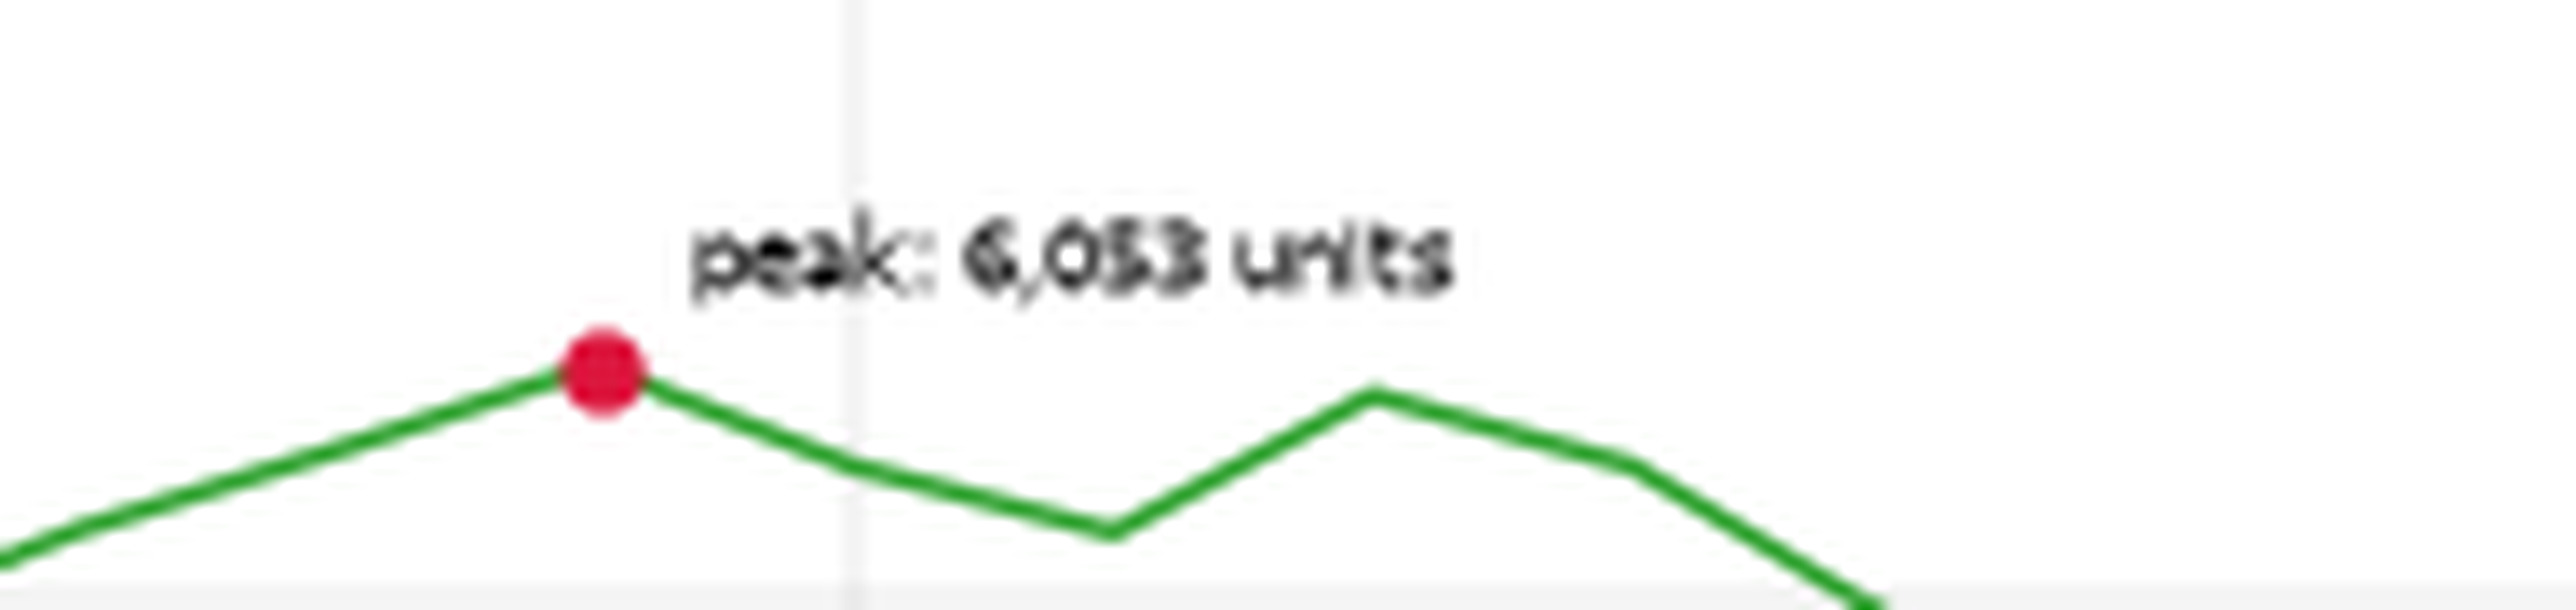

[Assistant] The annotation at the peak of the Widget-C line reads **"peak: 6,053 units"** — so the exact annotated value is **6,053 units**.

Ground truth (we drew it): peak: 6,053 units


In [7]:
print(f"Question: {question}\n")

print("Claude's analysis:\n")
final_answer = ask_with_zoom_tool(chart_image, question)

print(f"\nGround truth (we drew it): {answer}")

## When the Full View Lies

Reading small text is only half the failure mode — the other half is *geometry*. At month 48 of this same chart, the Widget-A and Widget-E lines sit about 26 units apart: roughly 8 pixels in this rendering, a fraction of one 28×28 patch, with a genuine crossing nearby to confuse matters further. An ordering question at that separation physically cannot be resolved at patch granularity.

Ask without the tool, and Claude confidently picks the wrong line — in 36 of 40 recorded runs. With the zoom tool, it magnifies the crossing region (zooming in repeatedly, each crop tighter than the last) and gets it right — in 40 of 40.

> **Note:** this near-tie contrast is tuned for `claude-fable-5`, the strongest chart reader in the benchmark above. Smaller models miss it much more often even with the tool — in our runs, `claude-sonnet-5` called this crossing correctly only once in 10 attempts with the tool available. The zoom recovers the pixels; calling an almost-touching crossing still takes the model's best visual reasoning.

WITHOUT the tool:
**Widget-A** has the higher value at month 48. The blue Widget-A line is rising steeply at that point (around ~5,350 units), having just crossed above the purple Widget-E line, which is declining (around ~5,300 units). The two lines cross at roughly month 47, so by month 48 Widget-A is slightly above Widget-E.

WITH the zoom tool:


[Tool] zoom({'x1': 980, 'y1': 230, 'x2': 1120, 'y2': 360})


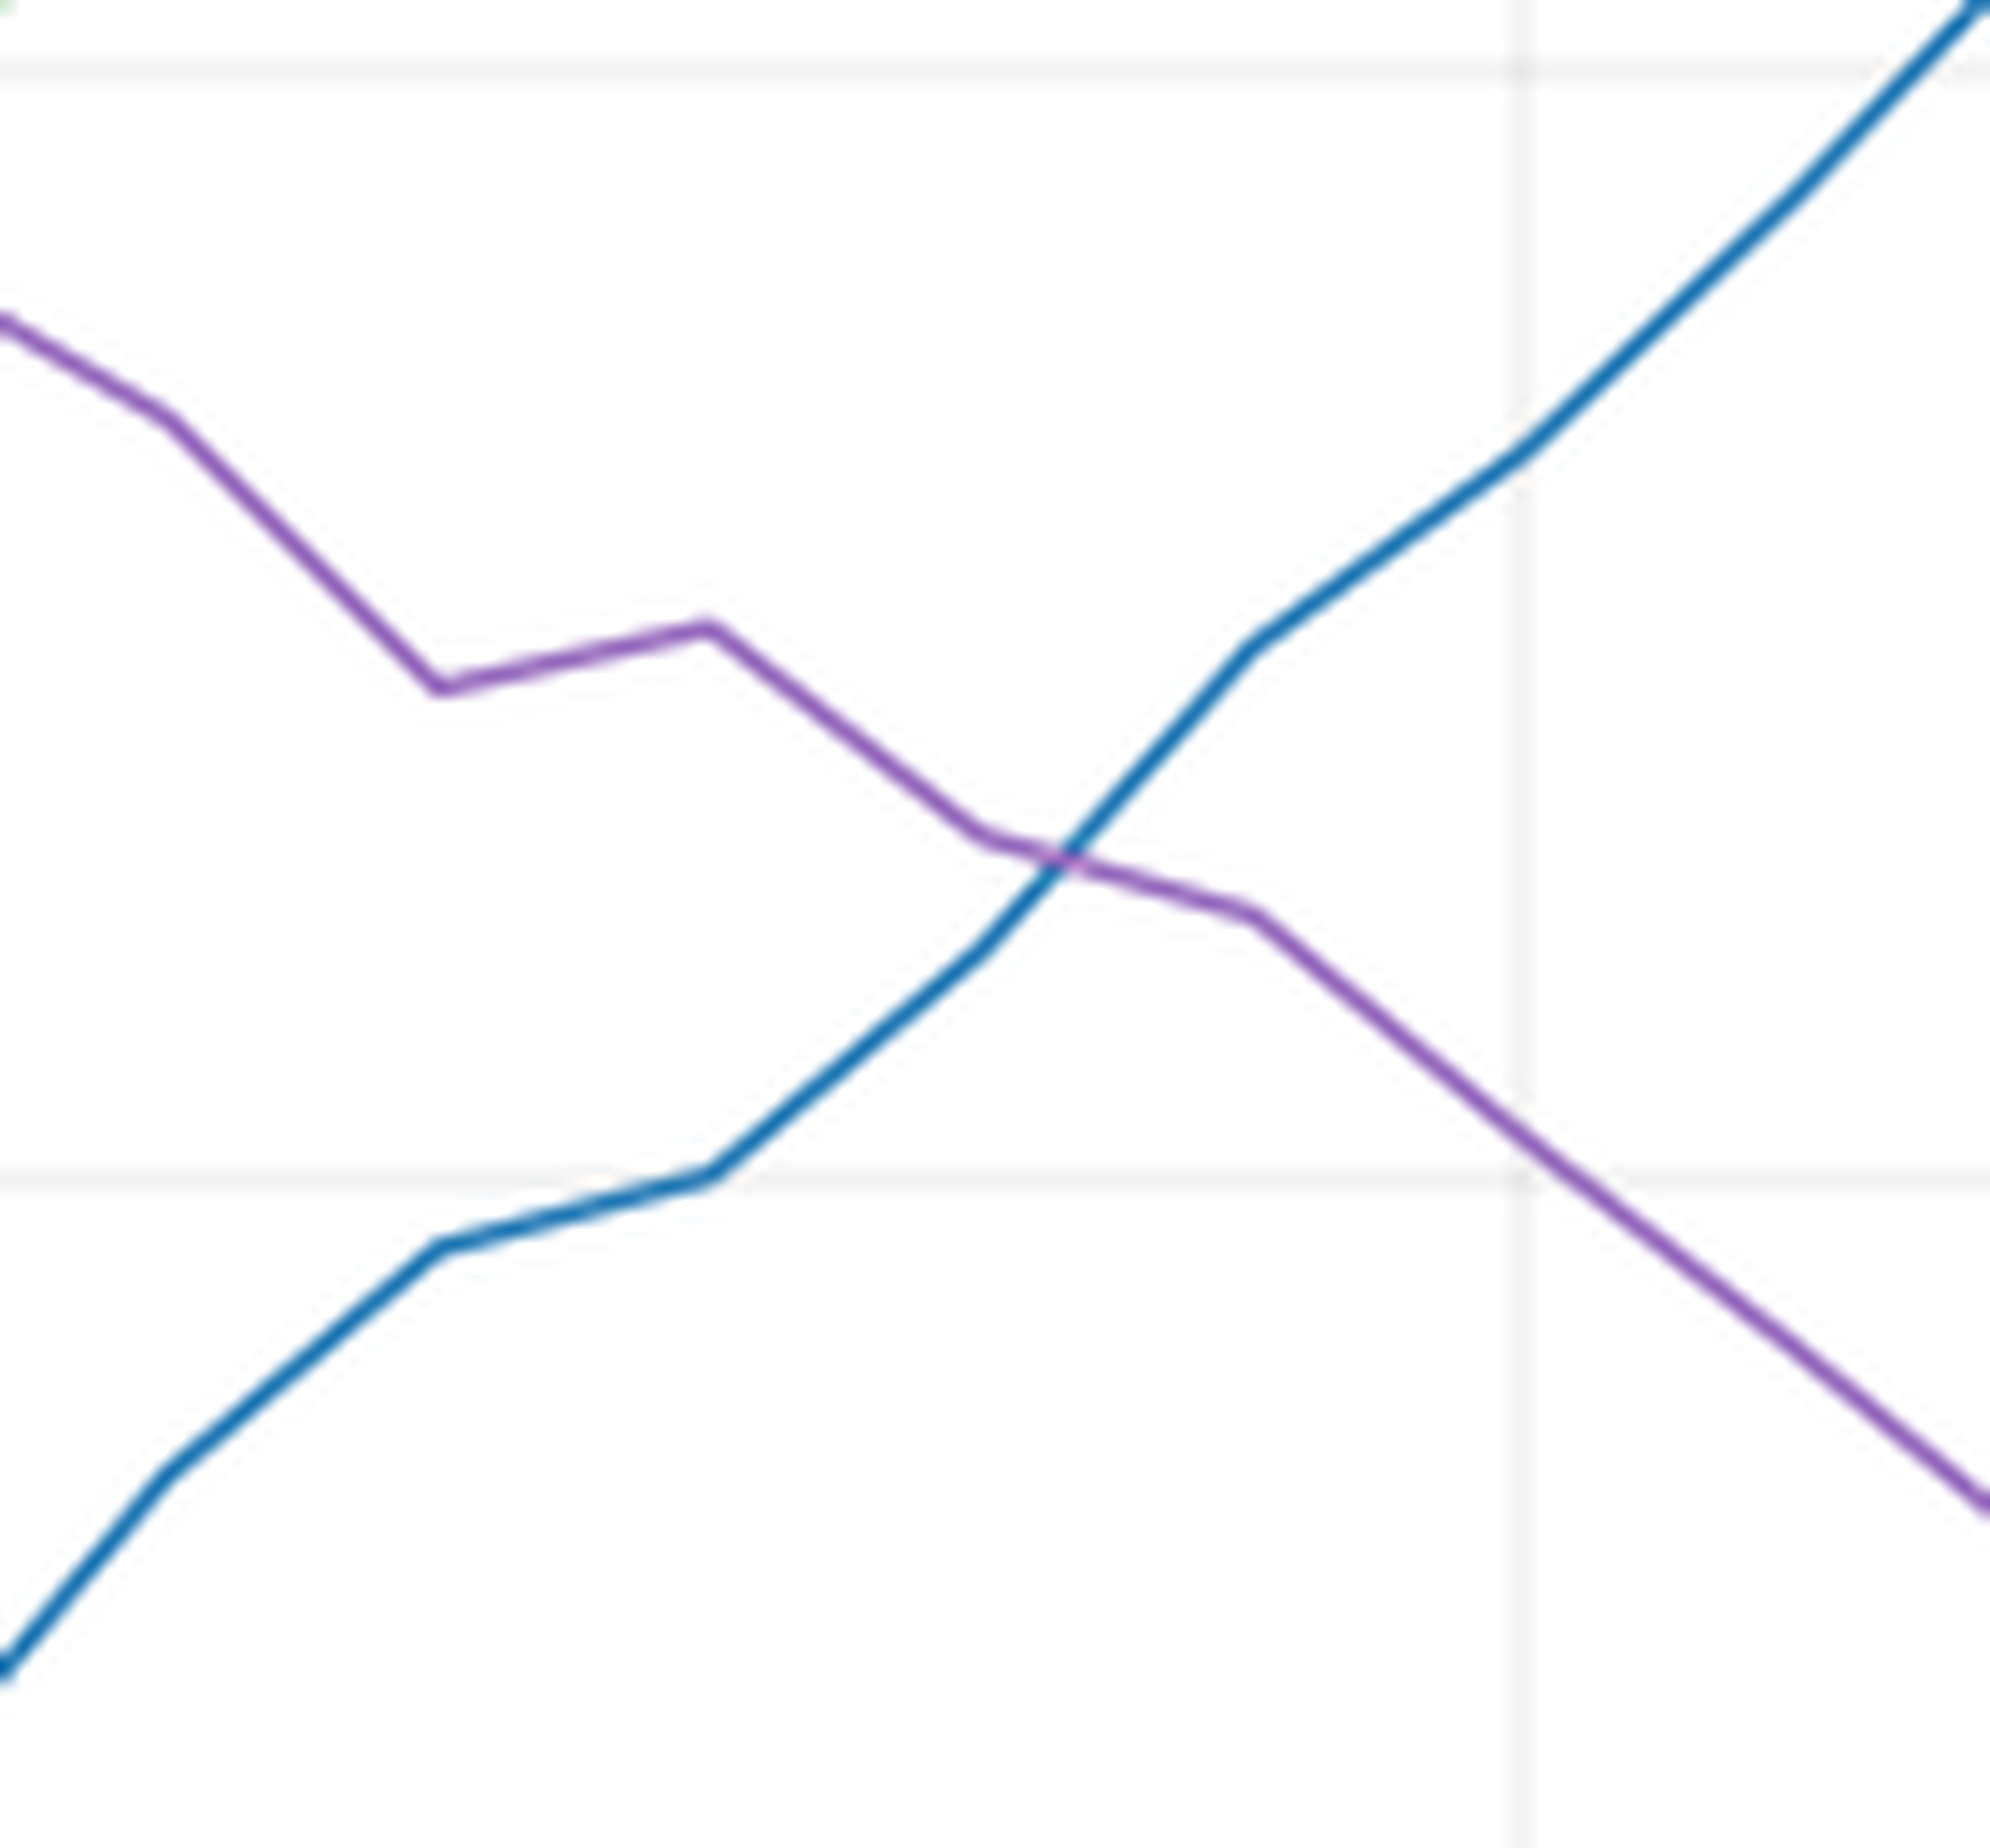

[Tool] zoom({'x1': 1025, 'y1': 270, 'x2': 1075, 'y2': 320})


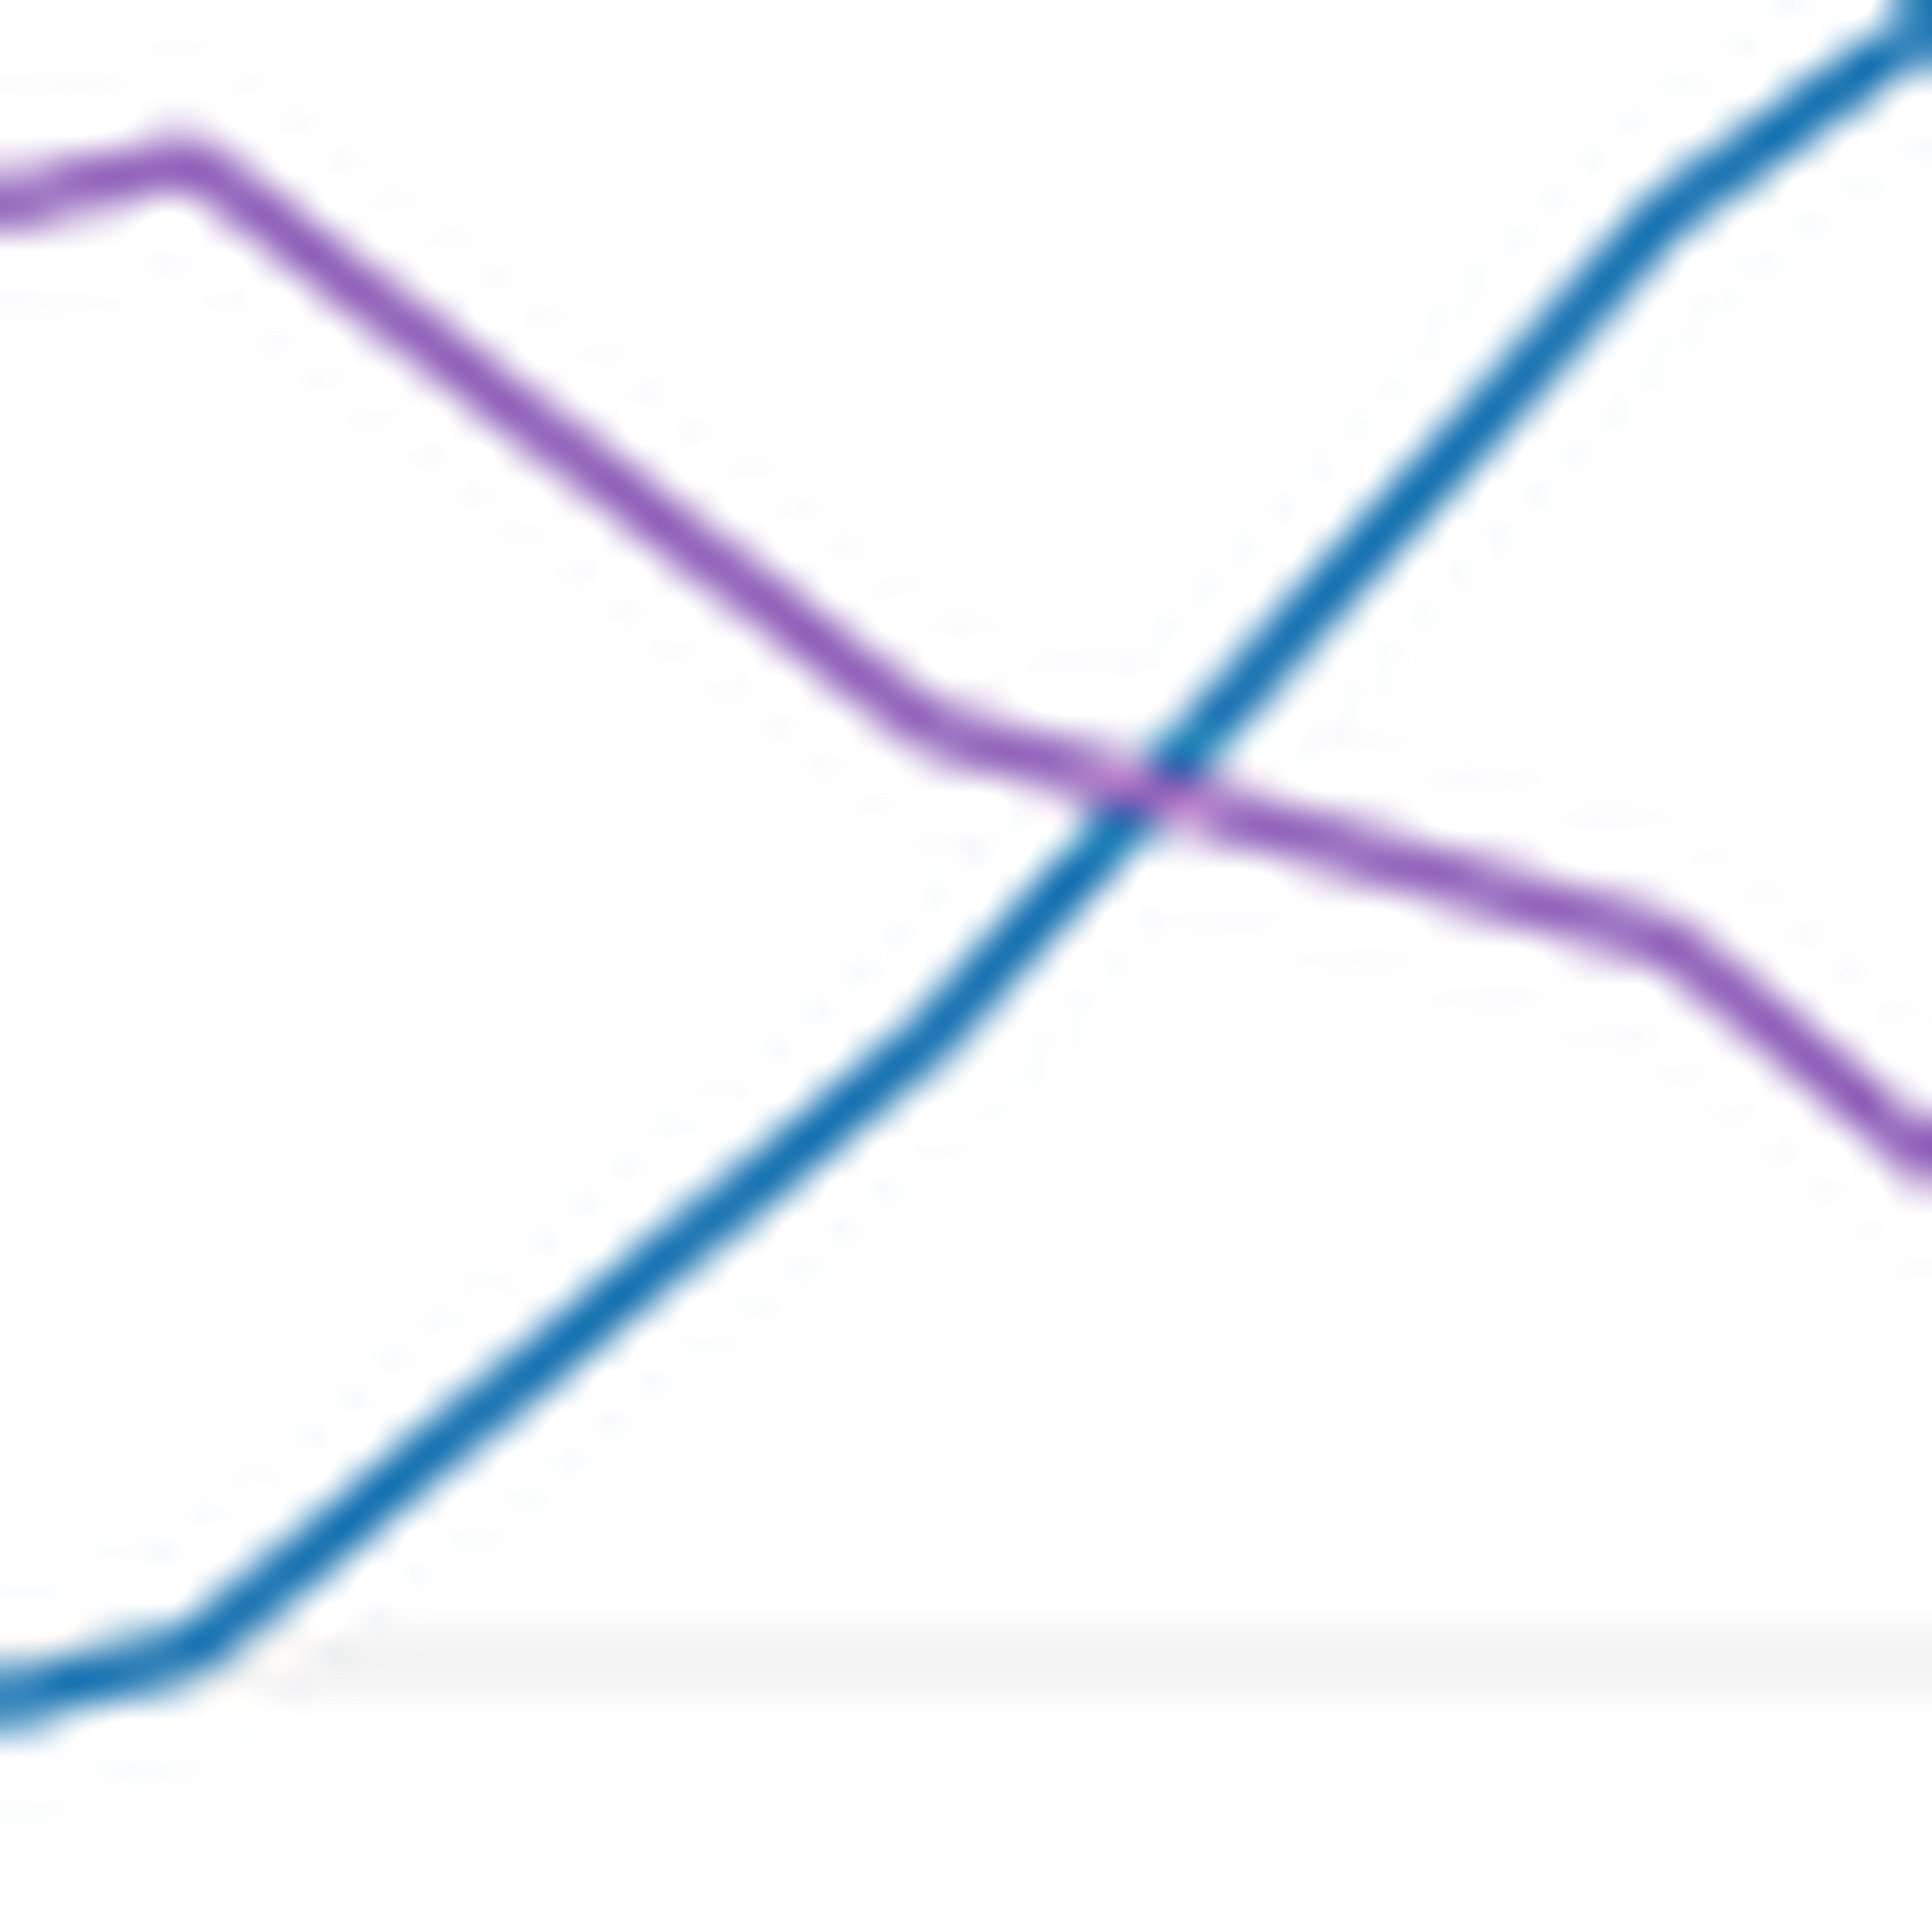

[Assistant] **Widget-E** has the higher value at month 48.

Zooming in on that region shows the purple Widget-E line (around ~5,310 units) sits just above the blue Widget-A line (around ~5,290 units) at month 48. The two lines cross shortly after — at roughly month 48–49 — after which Widget-A overtakes Widget-E, but at exactly month 48, Widget-E is still slightly higher.

Ground truth (from the data): Widget-E is higher at month 48, by about 26 units.


In [8]:
question_2 = "At month 48, which product line has the higher value: Widget-A or Widget-E?"

# Without the tool: one plain Messages call, same image
view = prepare_image(chart_image)
response = client.messages.create(
    model=MODEL,
    max_tokens=8192,
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": f"Answer the following question about the image below.\n\nThe question is: {question_2}",
                },
                {
                    "type": "image",
                    "source": {
                        "type": "base64",
                        "media_type": "image/png",
                        "data": pil_to_base64(view),
                    },
                },
            ],
        }
    ],
)
print("WITHOUT the tool:")
print("".join(block.text for block in response.content if block.type == "text"))

print("\nWITH the zoom tool:")
ask_with_zoom_tool(chart_image, question_2)

higher = "Widget-E" if series["Widget-E"][48] > series["Widget-A"][48] else "Widget-A"
gap = abs(series["Widget-E"][48] - series["Widget-A"][48])
print(f"\nGround truth (from the data): {higher} is higher at month 48, by about {gap:.0f} units.")

Here is that exchange in motion — the full view, the model's zoom call, and the magnified crop where the two lines finally separate:

![Animated walkthrough of the zoom exchange: the full chart appears with the question; without the tool, the model answers Widget-A, marked wrong; the view then zooms in twice, each crop tighter than the last, until the magnified crossing shows the Widget-E line still above Widget-A at month 48; with the tool, the model answers Widget-E, marked correct.](../images/crop_tool/zoom_demo.gif)

## Multi-Image Conversations

When a conversation contains several images, the tool needs to know *which* image to zoom into. The schema above already includes an optional `image_index` parameter (0 for the first image, 1 for the second, and so on), and `ask_with_zoom_tool()` accepts a list:

```python
ask_with_zoom_tool([chart_image, other_chart], "Which of the two charts has more categories?")
```

Each image is labeled with its index and pixel dimensions in the prompt, so Claude can name the image it wants and use the right coordinate space for it.

## Summary

The zoom tool pattern:

1. **Pre-resize** the image you send with `resized_size()`, so Claude's pixel coordinates map 1:1 onto the image you have — and state the dimensions and the top-left origin in your prompt.
2. **Define a zoom tool** that takes absolute pixel coordinates.
3. **Crop from the full-resolution original**, not from the downscaled copy, and **scale the crop up** to the model's image budget, so small elements get enough visual tokens to be read.
4. **Let Claude decide** when and where to zoom.

This works because Claude can see the full image first, identify the regions that need closer inspection, and re-read them magnified. The trade-off: each zoom call adds a model round-trip and the zoomed image costs visual tokens, so expect better accuracy on detail-bound questions in exchange for higher latency and token usage. (And if you run Claude in an agent framework with code execution, you may not need to build any of this: an agent that can run code will typically write its own crop-and-magnify script on demand — the same pattern, self-served.)

## Appendix: The Loop, By Hand

`tool_runner` is a convenience; everything it does can be written out with plain `client.messages.create` calls, and seeing the mechanics once is worth it — this is also where you control every edge case yourself: executing tool calls whenever they appear (even on a token-capped turn), resuming server-paused turns, giving the model one plain turn to answer when a token-capped turn produced neither a tool call nor any text, and dispatching tool names explicitly (unknown names get an error result back, so a model that hallucinates a tool can recover).

The version below is equivalent to the runner version in the common path, with two deliberate differences: the runner bounds iterations at 20 and pause-turn re-entries at 5, while this version runs until the model stops — add your own cap for production use.

In [9]:
from anthropic.types import (
    ContentBlockParam,
    ImageBlockParam,
    MessageParam,
    TextBlockParam,
    ToolResultBlockParam,
)


def ask_with_zoom_tool_manual(
    images, question: str, verbose: bool = True, model: str = MODEL
) -> str:
    """Ask Claude a question about one or more images, with the zoom tool available.

    Accepts a single PIL image or a list of them. Returns Claude's final text.
    """
    originals = images if isinstance(images, list) else [images]
    views = [prepare_image(image) for image in originals]

    content: list[ContentBlockParam] = [
        {
            "type": "text",
            "text": f"Answer the following question about the image below.\n\nThe question is: {question}",
        }
    ]
    for i, view in enumerate(views):
        label = f"Image {i}" if len(views) > 1 else "The image"
        content.append({"type": "text", "text": f"\n{label} is {view.width}x{view.height} pixels:"})
        content.append(
            {
                "type": "image",
                "source": {
                    "type": "base64",
                    "media_type": "image/png",
                    "data": pil_to_base64(view),
                },
            }
        )
    content.append(
        {
            "type": "text",
            "text": (
                "\nPixel coordinates start at (0, 0) in the top-left corner, with x increasing "
                "to the right and y increasing downward. Use the zoom tool to examine small "
                "details like legends, axis labels, and closely spaced values."
            ),
        }
    )

    messages: list[MessageParam] = [{"role": "user", "content": content}]
    nudged = False

    while True:
        response = client.messages.create(
            model=model, max_tokens=8192, tools=[ZOOM_TOOL], messages=messages
        )

        if verbose:
            for block in response.content:
                if block.type == "text":
                    print(f"[Assistant] {block.text}")
                elif block.type == "tool_use":
                    print(f"[Tool] zoom({block.input})")

        if response.stop_reason == "pause_turn":
            # The model paused a long turn; hand it back as-is and let it continue.
            messages.append({"role": "assistant", "content": response.content})
            continue

        tool_calls = [block for block in response.content if block.type == "tool_use"]

        if tool_calls:
            # Execute the tool calls and continue — keyed on the presence of the
            # calls rather than on stop_reason, so a turn that emitted a complete
            # call and then hit the token cap still gets its tool result.
            messages.append({"role": "assistant", "content": response.content})

            tool_results: list[ToolResultBlockParam] = []
            for block in tool_calls:
                if block.name != "zoom":
                    # Dispatch by name: when you add more tools, route each name
                    # to its handler here. Unknown names get an error result.
                    tool_results.append(
                        {
                            "type": "tool_result",
                            "tool_use_id": block.id,
                            "content": f"Unknown tool: {block.name}",
                            "is_error": True,
                        }
                    )
                    continue
                # block.input is typed loosely; the tool call's arguments arrive as a dict.
                inputs = dict(cast(Mapping[str, Any], block.input))
                image_index = inputs.pop("image_index", 0)
                if not 0 <= image_index < len(originals):
                    result: list[TextBlockParam | ImageBlockParam] = [
                        {
                            "type": "text",
                            "text": f"Error: image_index {image_index} is out of range",
                        }
                    ]
                else:
                    try:
                        result = handle_zoom(
                            originals[image_index], views[image_index].size, **inputs
                        )
                    except TypeError as e:
                        # A malformed call (e.g. a missing coordinate, possible when a
                        # turn is cut off mid-call) gets an error result back, so the
                        # model can correct itself instead of crashing the loop.
                        result = [{"type": "text", "text": f"Error: invalid zoom arguments ({e})"}]
                if verbose:
                    show_tool_result(result, show_text=False)
                tool_results.append(
                    {"type": "tool_result", "tool_use_id": block.id, "content": result}
                )

            messages.append({"role": "user", "content": tool_results})
            continue

        if (
            response.stop_reason == "max_tokens"
            and not any(block.type == "text" for block in response.content)
            and response.content
            and not nudged
        ):
            # The turn hit the token cap mid-thought: no answer text, no tool call.
            # Hand the partial turn back and ask for a concise wrap-up (once).
            nudged = True
            messages.append({"role": "assistant", "content": response.content})
            messages.append(
                {
                    "role": "user",
                    "content": "You ran out of output tokens. State your final answer concisely now.",
                }
            )
            continue

        # Join every text block of the final turn: models that think can emit
        # several, and the answer is not always in the last one.
        return "\n".join(block.text for block in response.content if block.type == "text")